In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
df = pd.read_csv("weatherAUS.csv")

In [4]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


In [6]:
#Handling missing data

threshold = len(df) * 0.60
df1 = df.dropna(thresh=threshold, axis=1)
print(df1.shape)

df2 = df1.copy()
df2.dropna(inplace=True)
df2.info()

(145460, 20)
<class 'pandas.DataFrame'>
Index: 75615 entries, 0 to 145458
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           75615 non-null  str    
 1   Location       75615 non-null  str    
 2   MinTemp        75615 non-null  float64
 3   MaxTemp        75615 non-null  float64
 4   Rainfall       75615 non-null  float64
 5   WindGustDir    75615 non-null  str    
 6   WindGustSpeed  75615 non-null  float64
 7   WindDir9am     75615 non-null  str    
 8   WindDir3pm     75615 non-null  str    
 9   WindSpeed9am   75615 non-null  float64
 10  WindSpeed3pm   75615 non-null  float64
 11  Humidity9am    75615 non-null  float64
 12  Humidity3pm    75615 non-null  float64
 13  Pressure9am    75615 non-null  float64
 14  Pressure3pm    75615 non-null  float64
 15  Cloud9am       75615 non-null  float64
 16  Temp9am        75615 non-null  float64
 17  Temp3pm        75615 non-null  float64
 18  RainToda

In [7]:
#Encoding the wind directions

df3 = df2.copy()
df3 = pd.get_dummies(df2, columns=['WindGustDir','WindDir9am','WindDir3pm'], dtype=float)
df3

,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,2008-12-01,Albury,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2008-12-05,Albury,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2008-12-07,Albury,14.3,25.0,0.0,50.0,20.0,24.0,49.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11,2008-12-12,Albury,15.9,21.7,2.2,31.0,15.0,13.0,89.0,91.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2008-12-13,Albury,15.9,18.6,15.6,61.0,28.0,28.0,76.0,93.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145428,2017-05-25,Uluru,14.6,26.3,0.0,37.0,19.0,20.0,61.0,36.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145431,2017-05-28,Uluru,8.0,24.6,0.0,33.0,11.0,13.0,46.0,25.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145432,2017-05-29,Uluru,12.7,22.2,0.0,37.0,19.0,13.0,59.0,34.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145433,2017-05-30,Uluru,9.4,22.7,0.0,35.0,13.0,17.0,62.0,32.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
#Label Encoding the boolean values

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df4 = df3.copy()
df4['RainToday'] = le.fit_transform(df4['RainToday'])
df4['RainTomorrow'] = le.fit_transform(df4['RainTomorrow'])
df4.loc[0:10,'RainTomorrow']

0    0
4    0
6    0
Name: RainTomorrow, dtype: int64

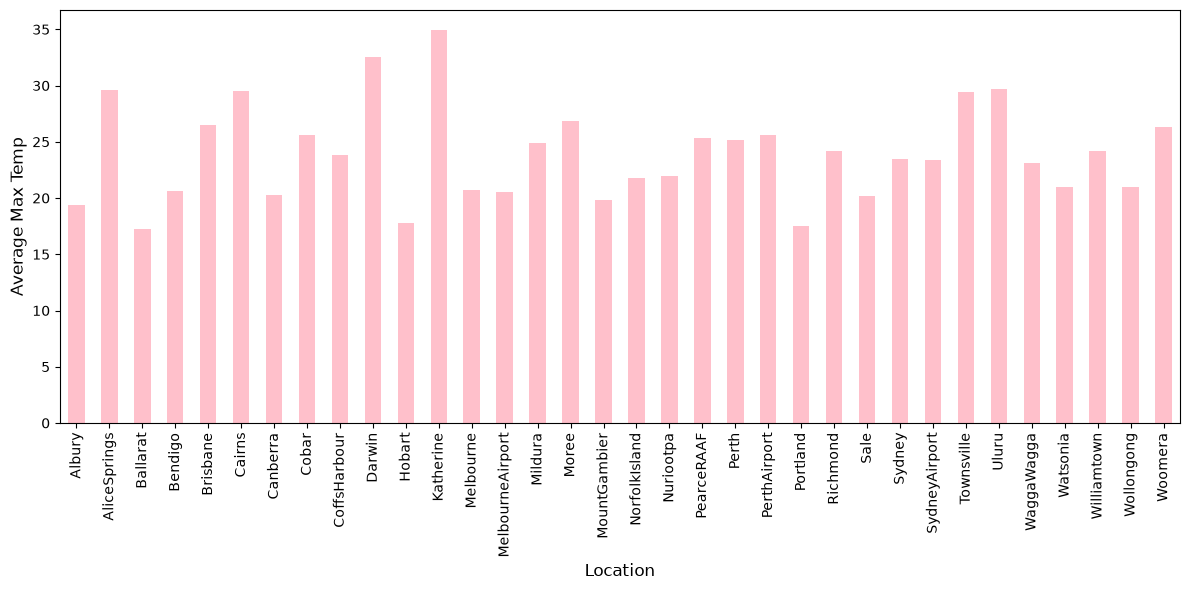

In [11]:
cities = df4.groupby("Location", as_index='False')["MaxTemp"].mean()
plt.figure(figsize=(12, 6))
cities.plot(kind='bar', color='pink')
plt.xlabel('Location', fontsize=12)
plt.ylabel('Average Max Temp', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
#Each city will have different outliers so iqr encoding must be used on one city at a time
num_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
            'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
            'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Temp9am', 'Temp3pm']

df_clipped = df4.copy()

for loc, group in df4.groupby('Location'):
    q1 = group[num_cols].quantile(0.25)
    q3 = group[num_cols].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df_clipped.loc[group.index, num_cols] = group[num_cols].clip(lower, upper, axis=1)

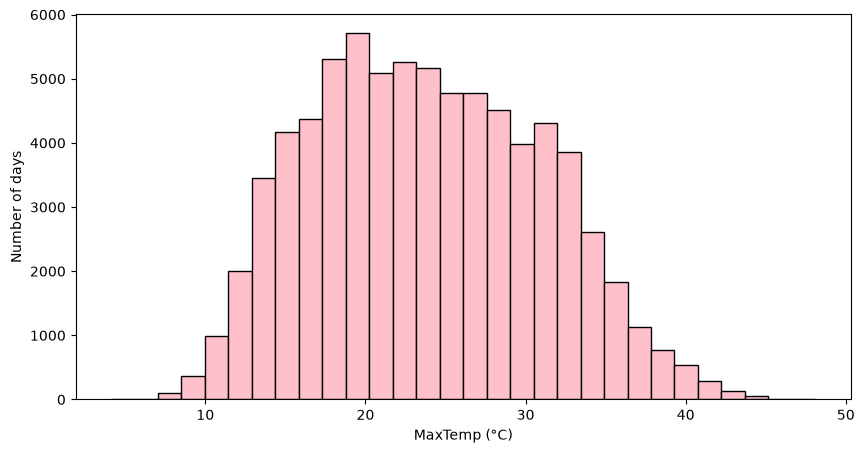

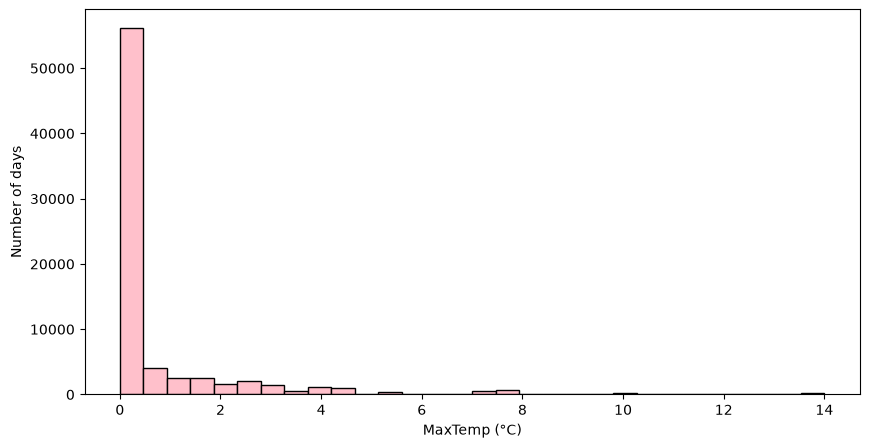

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(df_clipped['MaxTemp'], bins=30, color='pink', edgecolor='black')
plt.xlabel('MaxTemp (°C)')
plt.ylabel('Number of days')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df_clipped['Rainfall'], bins=30, color='pink', edgecolor='black')
plt.xlabel('MaxTemp (°C)')
plt.ylabel('Number of days')
plt.show()

In [20]:
#Normalising
from sklearn.preprocessing import MinMaxScaler

df_scaled = df_clipped.copy()

for loc, group in df_clipped.groupby('Location'):
    scaler = MinMaxScaler()
    df_scaled.loc[group.index, num_cols] = scaler.fit_transform(group[num_cols])
df_scaled

,Date,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,2008-12-01,Albury,0.547297,0.492355,0.059259,0.485294,0.679245,0.637681,0.472727,0.128492,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2008-12-05,Albury,0.685811,0.779817,0.098765,0.441176,0.188679,0.521739,0.672727,0.251397,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2008-12-07,Albury,0.577703,0.556575,0.000000,0.573529,0.679245,0.637681,0.072727,0.094972,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
11,2008-12-12,Albury,0.631757,0.455657,0.217284,0.294118,0.490566,0.318841,0.800000,0.899441,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2008-12-13,Albury,0.631757,0.360856,1.000000,0.735294,0.981132,0.753623,0.563636,0.921788,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145428,2017-05-25,Uluru,0.450704,0.458716,0.000000,0.336634,0.507463,0.493151,0.580645,0.428835,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145431,2017-05-28,Uluru,0.218310,0.406728,0.000000,0.257426,0.268657,0.301370,0.419355,0.266174,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145432,2017-05-29,Uluru,0.383803,0.333333,0.000000,0.336634,0.507463,0.301370,0.559140,0.399261,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
145433,2017-05-30,Uluru,0.267606,0.348624,0.000000,0.297030,0.328358,0.410959,0.591398,0.369686,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
from sklearn.model_selection import train_test_split

X = df_scaled.drop(columns=['RainTomorrow', 'Date', 'Location'])
y = df_scaled['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

print(X_train.shape, X_test.shape)

(60492, 62) (15123, 62)


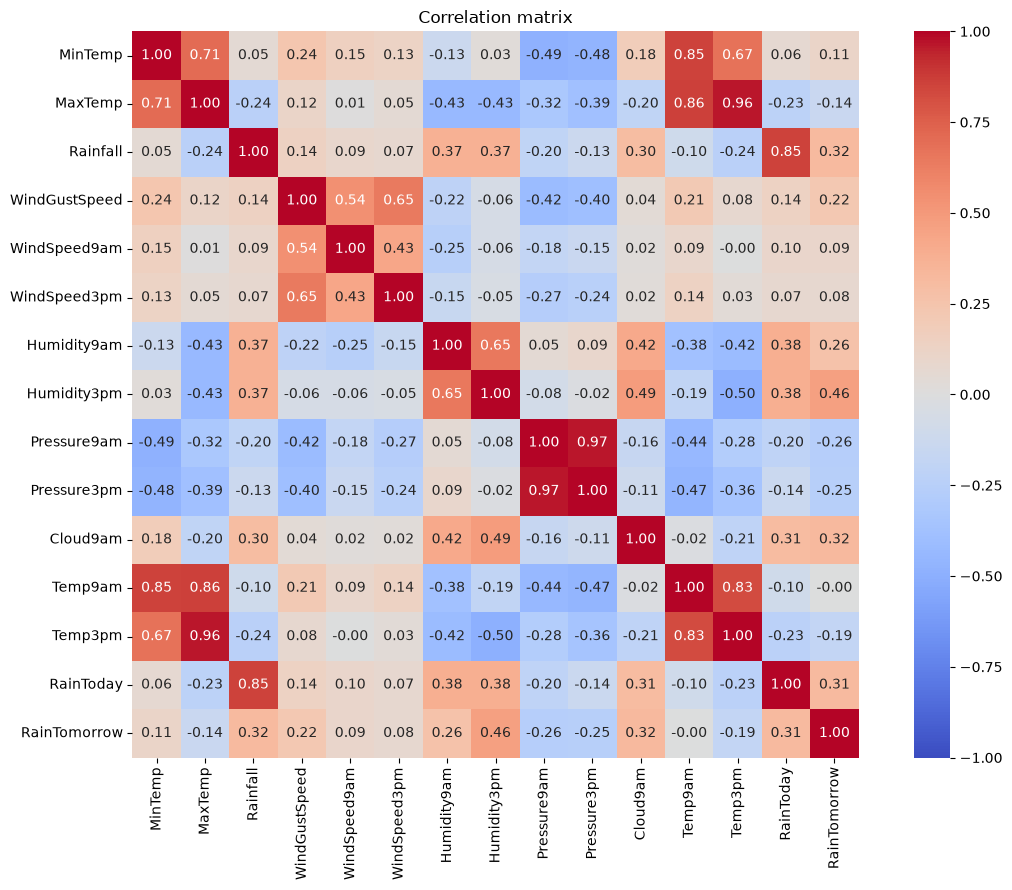

In [24]:
corr_cols = num_cols + ['RainToday', 'RainTomorrow']
corr = df_scaled[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()